Load core libraries for data and plots.

In [1]:
import pandas as pd
import plotly.express as px
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Load the dataset into a dataframe.

In [2]:
medical_df = pd.read_csv('medical.csv')
medical_df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
medical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
medical_df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Age

In [5]:
medical_df.age.describe()

count    1338.000000
mean       39.207025
std        14.049960
min        18.000000
25%        27.000000
50%        39.000000
75%        51.000000
max        64.000000
Name: age, dtype: float64

View the age distribution.

In [6]:
fig = px.histogram(medical_df,
                   x='age',
                   marginal='box',
                   nbins=47,
                   title='Distribution of Age')
fig.update_layout(bargap=0.1)
fig.show()

Body Mass Index

View the BMI distribution.

In [7]:
fig = px.histogram(medical_df,
                   x='bmi',
                   marginal='box',
                   color_discrete_sequence=['red'],
                   title='Distribution of BMI')
fig.update_layout(bargap=0.1)
fig.show()

Charges

Compare charge distribution by smoker status.

In [8]:
fig = px.histogram(medical_df, 
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['red','grey'],
                   title='Distribution of Charges')
fig.update_layout(bargap=0.1)
fig.show()

In [9]:
medical_df.smoker.value_counts()

smoker
no     1064
yes     274
Name: count, dtype: int64

In [10]:
fig = px.histogram(medical_df, 
                    x='smoker',
                    color='sex',
                    title='Smoker vs Non-Smoker')
fig.update_layout(bargap=0.1)
fig.show()

Age and charges

Check how age relates to charges.

In [11]:
fig = px.scatter(medical_df,
                     x='age',
                     y='charges',
                     color='smoker',
                     opacity=0.5,
                     hover_data=['sex','bmi'],
                     title='Age vs Charges')
fig.update_traces(marker_size=5)
fig.show()

BMI vs Charges

Check how BMI relates to charges.

In [12]:
fig = px.scatter(medical_df, 
                    x='bmi',
                    y ='charges',
                    color='smoker',
                    opacity=0.5,
                    title='BMI vs Charges')
fig.update_traces(marker_size=5)
fig.show()

In [13]:
fig = px.violin(medical_df,
                x="children",
                y="charges",
                title='Charges vs Number of Children')
fig.show()

### Correlation


Compute correlations and visualize them.

In [14]:
medical_df.charges.corr(medical_df.age)

np.float64(0.2990081933306478)

In [15]:
medical_df.charges.corr(medical_df.bmi)

np.float64(0.19834096883362887)

In [16]:
smoker_numeric = medical_df.smoker.map({'yes':1, 'no':0})
medical_df['smoker_numeric'] = smoker_numeric
medical_df.charges.corr(medical_df.smoker_numeric)

np.float64(0.7872514304984778)

<Axes: >

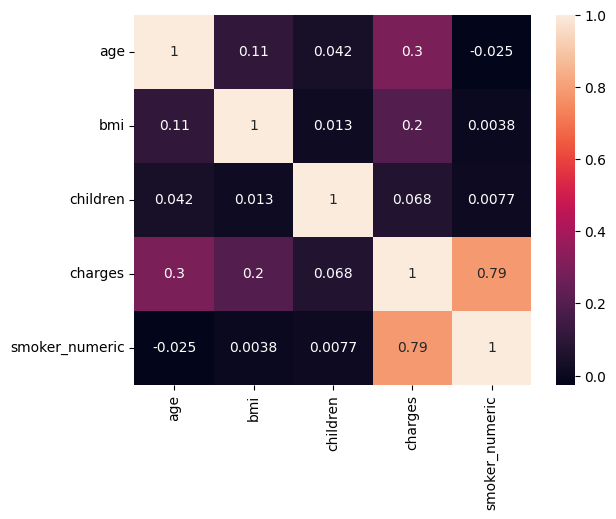

In [17]:
medical_df.corr(numeric_only=True)
sns.heatmap(medical_df.corr(numeric_only=True), annot=True)